### **Sentiment Analysis with CNN**  

This notebook focuses on training and evaluating a Convolutional Neural Network (CNN) model for sentiment analysis using three datasets: Amazon Books Reviews, Sentiment140, and Yelp Reviews. The goal is to explore CNN-based architectures, including Bidirectional CNN (BiCNN) and Temporal Convolutional Networks (TCN), to improve sentiment classification accuracy.  

The workflow includes data loading, text preprocessing, model training, hyperparameter tuning, and evaluation. Additionally, augmented datasets are used to examine the model’s robustness to noisy data. Both BiCNN and TCN architectures are tested to compare their effectiveness in sentiment analysis.  

#### **1. CNN Model - Amazon Books Reviews**  
- **1.1. Loading Data**  
- **1.2. Data Preprocessing**  
- **1.3. Model Training**  
- **1.4. Searching for Best Model Parameters**  
  - **1.4.1. BiCNN**  
  - **1.4.2. TCN (Temporal Convolutional Network)**  
- **1.5. Model Evaluation on Test Data**  
- **1.6. Model Evaluation on Augmented Data**  
- **1.7. Save Model**  

#### **2. CNN Model - Sentiment140**  
- **2.1. Loading Data**  
- **2.2. Data Preprocessing**  
- **2.3. Model Training**  
- **2.4. Searching for Best Model Parameters**  
  - **2.4.1. BiCNN**  
  - **2.4.2. TCN (Temporal Convolutional Network)**  
- **2.5. Model Evaluation on Test Data**  
- **2.6. Model Evaluation on Augmented Data**  
- **2.7. Save Model**  

#### **3. CNN Model - Yelp Reviews**  
- **3.1. Loading Data**  
- **3.2. Data Preprocessing**  
- **3.3. Model Training**  
- **3.4. Searching for Best Model Parameters**  
  - **3.4.1. BiCNN**  
  - **3.4.2. TCN (Temporal Convolutional Network)**  
- **3.5. Model Evaluation on Test Data**  
- **3.6. Model Evaluation on Augmented Data**  
- **3.7. Save Model**  


In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, Lambda, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout, Input, BatchNormalization, Concatenate, Add, Activation, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from nltk.stem import WordNetLemmatizer

In [32]:
import os
import sys

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from preprocessing.data_utils import DataUtils
from models import train_cnn

In [33]:
# due to error with allocating GPU memory, the CPU will be used
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [34]:
models_output_dir = '../outputs/models/cnn'

In [35]:
import fasttext
import fasttext.util

# define the model file path
model_path = "../data/embeddings/cc.en.300.bin"

# download the FastText model if it does not exist
if not os.path.exists(model_path):
    fasttext.util.download_model('en', if_exists='ignore')  # download English FastText model (300D)

# load the FastText model
fasttext_model = fasttext.load_model(model_path)

In [36]:
# preprocess and tokenize data
def preprocess_data(df, max_length=128, vocab_size=10000):
    # initialize tokenizer and lemmatizer
    tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
    lemmatizer = WordNetLemmatizer()

    # remove missing or empty values
    df = df.dropna(subset=['Review']).copy()
    df = df[df['Review'].str.strip() != '']

    # extract texts and labels
    texts = df['Review'].astype(str).tolist()
    labels = df['Polarity'].values

    # apply lemmatization
    texts = [" ".join([lemmatizer.lemmatize(word) for word in text.split()]) for text in texts]

    # tokenize and pad sequences
    tokenizer.fit_on_texts(texts)
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

    return padded_sequences, np.array(labels), tokenizer

In [37]:
# preprocess and tokenize data using existing tokenizer
def tokenize_with_existing_tokenizer(df, tokenizer, max_length):
    texts = df['Review'].astype(str).tolist()
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    labels = df['Polarity'].values
    return padded_sequences, labels

# 1. CNN Model - Amazon Books Reviews

## 1.1. Loading Data

In [182]:
# load the dataset
amazon_file = '../data/preprocessed/amazon.csv'
amazon_df = pd.read_csv(amazon_file, engine='python', encoding="ISO-8859-1")

In [183]:
# preview the data
amazon_df.head()

,Polarity,Review
0,0,As a Man Stinketh
1,1,MY FAVORITE!!
2,1,Epic novel
3,1,Very good source for Web Applications Development
4,1,Great fantasy


In [184]:
train_val_amazon_df, test_amazon_df = train_test_split(
    amazon_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=amazon_df['Polarity']
)

In [185]:
train_amazon_df, val_amazon_df = train_test_split(
    train_val_amazon_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_amazon_df['Polarity']
)

In [186]:
DataUtils.count_reviews_by_polarity(train_amazon_df)

Number of reviews with Polarity=1: 49382
Number of reviews with Polarity=0: 49382


In [187]:
DataUtils.count_reviews_by_polarity(val_amazon_df)

Number of reviews with Polarity=1: 10585
Number of reviews with Polarity=0: 10584


In [188]:
DataUtils.count_reviews_by_polarity(test_amazon_df)

Number of reviews with Polarity=1: 10582
Number of reviews with Polarity=0: 10583


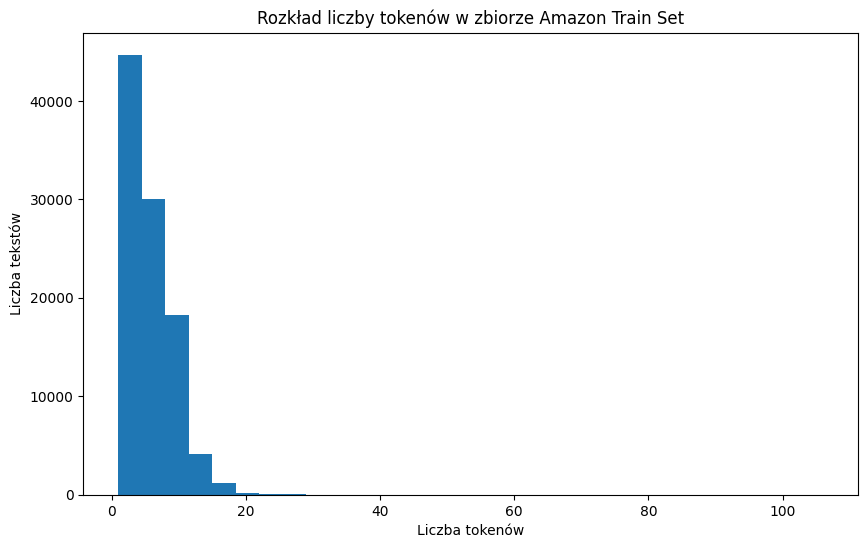

In [189]:
DataUtils.plot_token_distribution(train_amazon_df, "Amazon Train Set")

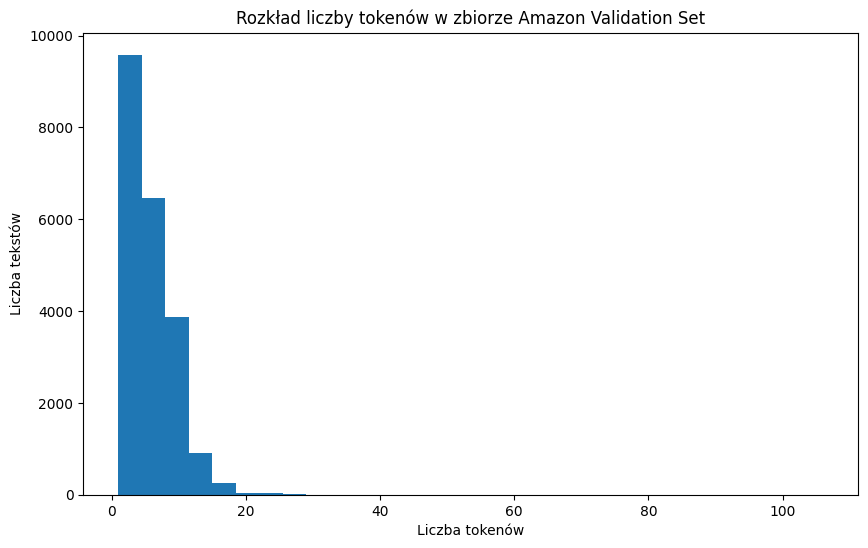

In [190]:
DataUtils.plot_token_distribution(val_amazon_df, "Amazon Validation Set")

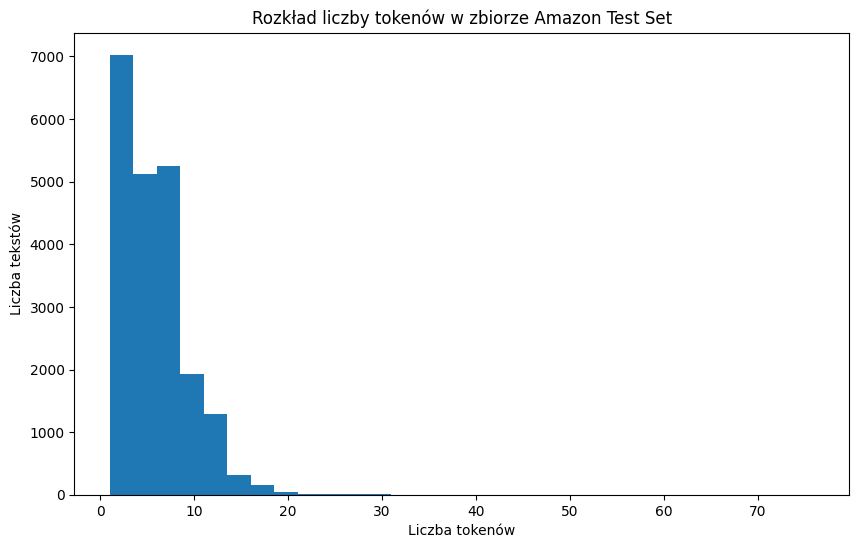

In [191]:
DataUtils.plot_token_distribution(test_amazon_df, "Amazon Test Set")

## 1.2. Data Preprocessing

In [192]:
# set preprocessing parameters
vocab_size = 12000  # maximum number of words in the tokenizer
max_length = 32  # maximum length of input sequences

In [193]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_amazon_df, max_length=max_length, vocab_size=vocab_size)

In [194]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_amazon_df, tokenizer, max_length)

In [195]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_amazon_df, tokenizer, max_length)

## 1.3. Model Training

In [196]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [197]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (12000, 300)


In [24]:
# define model architecture
model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    Conv1D(filters=128, kernel_size=2, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [25]:
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [26]:
model_cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 32, 300)           3600000   
                                                                 
 conv1d (Conv1D)             (None, 31, 128)           76928     
                                                                 
 global_max_pooling1d (Globa  (None, 128)              0         
 lMaxPooling1D)                                                  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 32)                4128      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                        

In [27]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [28]:
# train the model
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 15s 5ms/step - loss: 0.4314 - accuracy: 0.7948 - val_loss: 0.3905 - val_accuracy: 0.8124
Epoch 2/10
3087/3087 [==============================] - 15s 5ms/step - loss: 0.3827 - accuracy: 0.8205 - val_loss: 0.3757 - val_accuracy: 0.8268
Epoch 3/10
3087/3087 [==============================] - 14s 5ms/step - loss: 0.3654 - accuracy: 0.8296 - val_loss: 0.3681 - val_accuracy: 0.8304
Epoch 4/10
3087/3087 [==============================] - 14s 5ms/step - loss: 0.3534 - accuracy: 0.8360 - val_loss: 0.3693 - val_accuracy: 0.8277
Epoch 5/10
3087/3087 [==============================] - 14s 5ms/step - loss: 0.3424 - accuracy: 0.8420 - val_loss: 0.3602 - val_accuracy: 0.8348
Epoch 6/10
3087/3087 [==============================] - 14s 5ms/step - loss: 0.3358 - accuracy: 0.8461 - val_loss: 0.3599 - val_accuracy: 0.8351
Epoch 7/10
3087/3087 [==============================] - 14s 5ms/step - loss: 0.3270 - accuracy: 0.8518 - val_loss: 0.3615 - val_ac

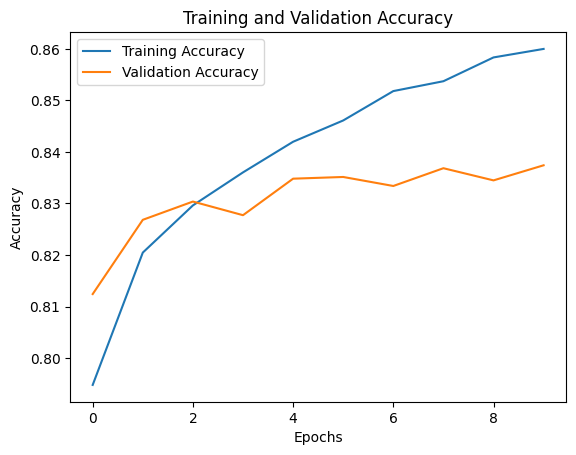

In [29]:
# plot accuracy on training and validation data
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

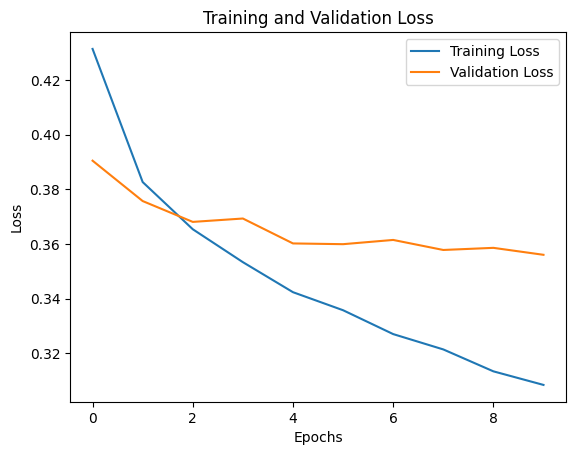

In [30]:
# plot loss on training and validation data
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [31]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_cnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0       0.84      0.83      0.84     10584
           1       0.84      0.84      0.84     10585

    accuracy                           0.84     21169
   macro avg       0.84      0.84      0.84     21169
weighted avg       0.84      0.84      0.84     21169



## 1.4. Searching for Best Model Parameters

### 1.4.1. BiCNN

In [32]:
def bicnn_amazon(vocab_size, learning_rate, embedding_dim, embedding_matrix):
    inputs = Input(shape=(32,))

    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=32, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # forward CNN (left-to-right processing)
    conv_fw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding)
    conv_fw = BatchNormalization()(conv_fw)  
    pool_fw1 = GlobalMaxPooling1D()(conv_fw) 
    pool_fw2 = GlobalAveragePooling1D()(conv_fw) 

    # backward CNN (right-to-left processing)
    reversed_embedding = Lambda(lambda x: tf.reverse(x, axis=[1]))(embedding)  # reverse embeddings 
    conv_bw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(reversed_embedding)
    conv_bw = BatchNormalization()(conv_bw)
    pool_bw1 = GlobalMaxPooling1D()(conv_bw)
    pool_bw2 = GlobalAveragePooling1D()(conv_bw)

    # concatenation of forward and backward features
    concat = Concatenate()([pool_fw1, pool_fw2, pool_bw1, pool_bw2])
    dropout = Dropout(0.5)(concat) 

    # fully connected layer for classification
    dense = Dense(256, activation='relu')(dropout)
    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)

    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model


In [33]:
model_bicnn = bicnn_amazon(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [34]:
model_bicnn.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 32)]         0           []                               
                                                                                                  
 embedding_1 (Embedding)        (None, 32, 300)      3600000     ['input_1[0][0]']                
                                                                                                  
 lambda (Lambda)                (None, 32, 300)      0           ['embedding_1[0][0]']            
                                                                                                  
 conv1d_1 (Conv1D)              (None, 32, 128)      115328      ['embedding_1[0][0]']            
                                                                                              

In [35]:
# train the model
history_bicnn = model_bicnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 38s 12ms/step - loss: 0.4606 - accuracy: 0.7791 - val_loss: 0.4390 - val_accuracy: 0.7915
Epoch 2/10
3087/3087 [==============================] - 36s 12ms/step - loss: 0.3959 - accuracy: 0.8113 - val_loss: 0.3883 - val_accuracy: 0.8209
Epoch 3/10
3087/3087 [==============================] - 35s 11ms/step - loss: 0.3772 - accuracy: 0.8221 - val_loss: 0.3798 - val_accuracy: 0.8237
Epoch 4/10
3087/3087 [==============================] - 36s 12ms/step - loss: 0.3655 - accuracy: 0.8280 - val_loss: 0.3670 - val_accuracy: 0.8266
Epoch 5/10
3087/3087 [==============================] - 34s 11ms/step - loss: 0.3524 - accuracy: 0.8354 - val_loss: 0.3596 - val_accuracy: 0.8322
Epoch 6/10
3087/3087 [==============================] - 34s 11ms/step - loss: 0.3441 - accuracy: 0.8391 - val_loss: 0.3633 - val_accuracy: 0.8312
Epoch 7/10
3087/3087 [==============================] - 34s 11ms/step - loss: 0.3333 - accuracy: 0.8458 - val_loss: 0.3595 -

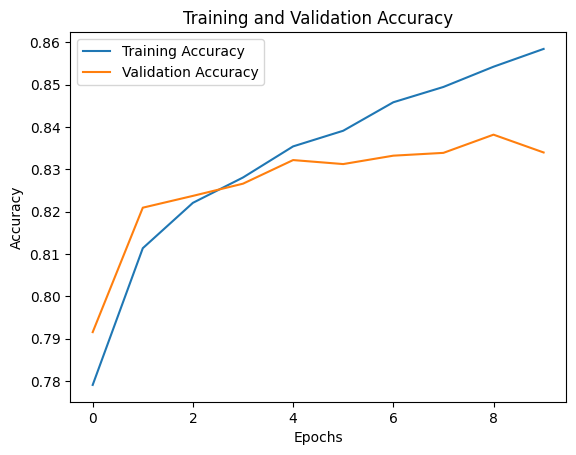

In [36]:
# plot accuracy on training and validation data
plt.plot(history_bicnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_bicnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

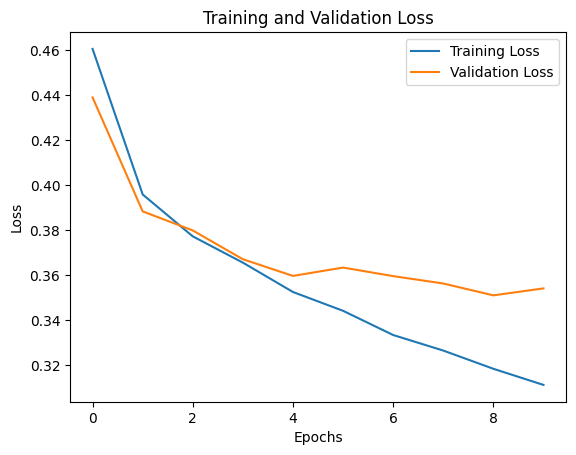

In [37]:
# plot loss on training and validation data
plt.plot(history_bicnn.history['loss'], label='Training Loss')
plt.plot(history_bicnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [38]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bicnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 3s 4ms/step
              precision    recall  f1-score   support

           0       0.83      0.84      0.83     10584
           1       0.84      0.83      0.83     10585

    accuracy                           0.83     21169
   macro avg       0.83      0.83      0.83     21169
weighted avg       0.83      0.83      0.83     21169



### 1.4.2. TCN (Temporal Convolutional Network) 

In [200]:
def tcn_model_amazon(vocab_size, embedding_dim, embedding_matrix, learning_rate, dilation_rates=[1, 2, 4, 8]):
    inputs = Input(shape=(32,))
    
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=32, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    x = embedding  # initialize feature extraction pipeline
    
    # multiple dilated convolutional layers
    for rate in dilation_rates:
        residual = Conv1D(filters=128, kernel_size=1, padding="same")(x)
        x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same', dilation_rate=rate)(x)
        x = BatchNormalization()(x)
        x = Dropout(0.2)(x)
        x = Add()([x, residual])  
        x = BatchNormalization()(x)
        x = Activation('relu')(x)

    pool1 = GlobalMaxPooling1D()(x)
    pool2 = GlobalAveragePooling1D()(x)
    concat = Concatenate()([pool1, pool2])

    dense = Dense(128, activation='relu')(concat)
    dropout = Dropout(0.3)(dense)
    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])

    return model

In [201]:
model_tcn = tcn_model_amazon(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [202]:
model_tcn.summary()

Model: "model_10"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_17 (InputLayer)          [(None, 32)]         0           []                               
                                                                                                  
 embedding_19 (Embedding)       (None, 32, 300)      3600000     ['input_17[0][0]']               
                                                                                                  
 conv1d_84 (Conv1D)             (None, 32, 128)      115328      ['embedding_19[0][0]']           
                                                                                                  
 batch_normalization_80 (BatchN  (None, 32, 128)     512         ['conv1d_84[0][0]']              
 ormalization)                                                                             

In [203]:
# train the model
history_tcn = model_tcn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 104s 33ms/step - loss: 0.4448 - accuracy: 0.7842 - val_loss: 0.3908 - val_accuracy: 0.8133
Epoch 2/10
3087/3087 [==============================] - 100s 33ms/step - loss: 0.3830 - accuracy: 0.8195 - val_loss: 0.3818 - val_accuracy: 0.8205
Epoch 3/10
3087/3087 [==============================] - 100s 32ms/step - loss: 0.3607 - accuracy: 0.8313 - val_loss: 0.3825 - val_accuracy: 0.8260
Epoch 4/10
3087/3087 [==============================] - 100s 32ms/step - loss: 0.3422 - accuracy: 0.8421 - val_loss: 0.3635 - val_accuracy: 0.8302
Epoch 5/10
3087/3087 [==============================] - 101s 33ms/step - loss: 0.3271 - accuracy: 0.8502 - val_loss: 0.3571 - val_accuracy: 0.8352
Epoch 6/10
3087/3087 [==============================] - 100s 33ms/step - loss: 0.3137 - accuracy: 0.8577 - val_loss: 0.3552 - val_accuracy: 0.8349
Epoch 7/10
3087/3087 [==============================] - 100s 33ms/step - loss: 0.3025 - accuracy: 0.8634 - val_loss: 0

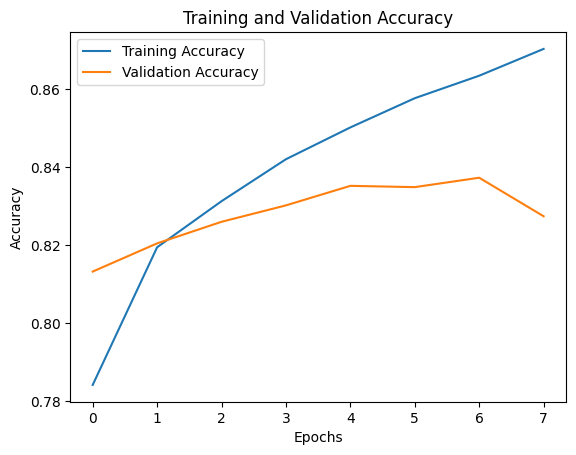

In [204]:
# plot accuracy on training and validation data
plt.plot(history_tcn.history['accuracy'], label='Training Accuracy')
plt.plot(history_tcn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

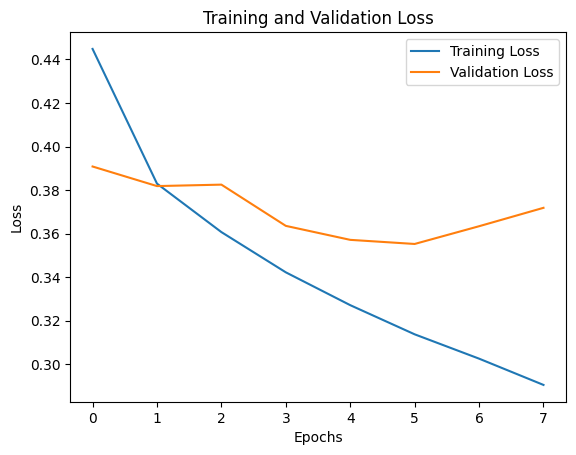

In [205]:
# plot loss on training and validation data
plt.plot(history_tcn.history['loss'], label='Training Loss')
plt.plot(history_tcn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [206]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_tcn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 6s 9ms/step
              precision    recall  f1-score   support

           0       0.87      0.79      0.83     10584
           1       0.81      0.88      0.84     10585

    accuracy                           0.83     21169
   macro avg       0.84      0.83      0.83     21169
weighted avg       0.84      0.83      0.83     21169



## 1.5. Model Evaluation on Test Data

In [46]:
train_cnn.evaluate_model(model=model_cnn, tokenizer=tokenizer, test_df=test_amazon_df, max_length=max_length)

662/662 [==============================] - 1s 2ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.84      0.84      0.84     10583
           1       0.84      0.84      0.84     10582

    accuracy                           0.84     21165
   macro avg       0.84      0.84      0.84     21165
weighted avg       0.84      0.84      0.84     21165



## 1.6. Model Evaluation on Augmented Data

In [47]:
# load the augmented test sets
test_amazon_char_swap_file = '../data/preprocessed/amazon_test_char_swap.csv'
test_amazon_char_swap_df = pd.read_csv(test_amazon_char_swap_file, engine='python', encoding="ISO-8859-1")

test_amazon_embedding_file = '../data/preprocessed/amazon_test_embedding.csv'
test_amazon_embedding_df = pd.read_csv(test_amazon_embedding_file, engine='python', encoding="ISO-8859-1")

test_amazon_eda_file = '../data/preprocessed/amazon_test_eda.csv'
test_amazon_eda_df = pd.read_csv(test_amazon_eda_file, engine='python', encoding="ISO-8859-1")

In [48]:
train_cnn.evaluate_model(model=model_cnn, tokenizer=tokenizer, test_df=test_amazon_char_swap_df, max_length=max_length)

662/662 [==============================] - 1s 2ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.73      0.79      0.76     10583
           1       0.77      0.71      0.74     10582

    accuracy                           0.75     21165
   macro avg       0.75      0.75      0.75     21165
weighted avg       0.75      0.75      0.75     21165



In [49]:
train_cnn.evaluate_model(model=model_cnn, tokenizer=tokenizer, test_df=test_amazon_embedding_df, max_length=max_length)


662/662 [==============================] - 1s 2ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.78      0.80      0.79     10583
           1       0.79      0.78      0.78     10582

    accuracy                           0.79     21165
   macro avg       0.79      0.79      0.79     21165
weighted avg       0.79      0.79      0.79     21165



In [50]:
train_cnn.evaluate_model(model=model_cnn, tokenizer=tokenizer, test_df=test_amazon_eda_df, max_length=max_length)


662/662 [==============================] - 1s 2ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.80      0.80     10583
           1       0.80      0.80      0.80     10582

    accuracy                           0.80     21165
   macro avg       0.80      0.80      0.80     21165
weighted avg       0.80      0.80      0.80     21165



## 1.7. Save Model

In [51]:
model_path = os.path.join(models_output_dir, "amazon_cnn_model.keras")
model_cnn.save(model_path)

# 2. CNN Model - Sentiment140

## 2.1. Loading Data

In [155]:
# load the dataset
sentiment140_file = '../data/preprocessed/sentiment140.csv'
sentiment140_df = pd.read_csv(sentiment140_file, engine='python', encoding="ISO-8859-1")

In [156]:
# preview the data
sentiment140_df.head()

,Polarity,Review
0,1,@Alicia_86 srry u get my tweet?
1,1,@jchiarelli TTS to take text Tweets to the pho...
2,1,Mmmm apple cinnomin oatmeal
3,1,@willwallaceii thanks man. the truth can be fu...
4,1,RAIN The plants and trees are happy ^~^


In [157]:
train_val_sentiment140_df, test_sentiment140_df = train_test_split(
    sentiment140_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=sentiment140_df['Polarity']
)

In [158]:
train_sentiment140_df, val_sentiment140_df = train_test_split(
    train_val_sentiment140_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_sentiment140_df['Polarity']
)

In [159]:
DataUtils.count_reviews_by_polarity(train_sentiment140_df)

Number of reviews with Polarity=1: 111996
Number of reviews with Polarity=0: 111996


In [160]:
DataUtils.count_reviews_by_polarity(val_sentiment140_df)

Number of reviews with Polarity=1: 24004
Number of reviews with Polarity=0: 24004


In [161]:
DataUtils.count_reviews_by_polarity(test_sentiment140_df)

Number of reviews with Polarity=1: 24000
Number of reviews with Polarity=0: 24000


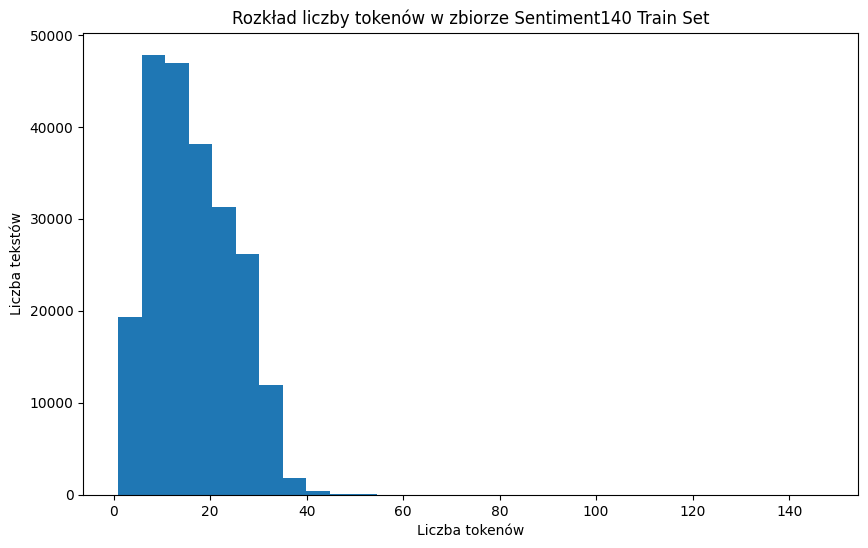

In [162]:
DataUtils.plot_token_distribution(train_sentiment140_df, "Sentiment140 Train Set")

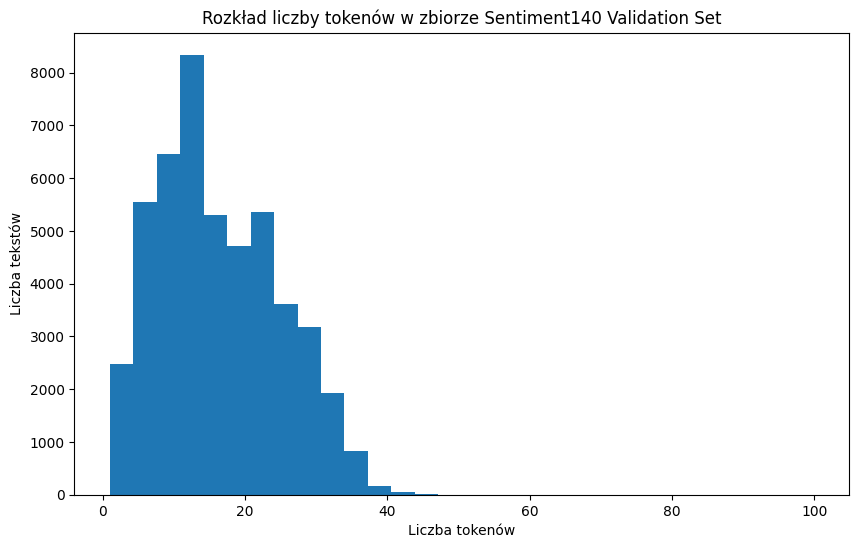

In [163]:
DataUtils.plot_token_distribution(val_sentiment140_df, "Sentiment140 Validation Set")

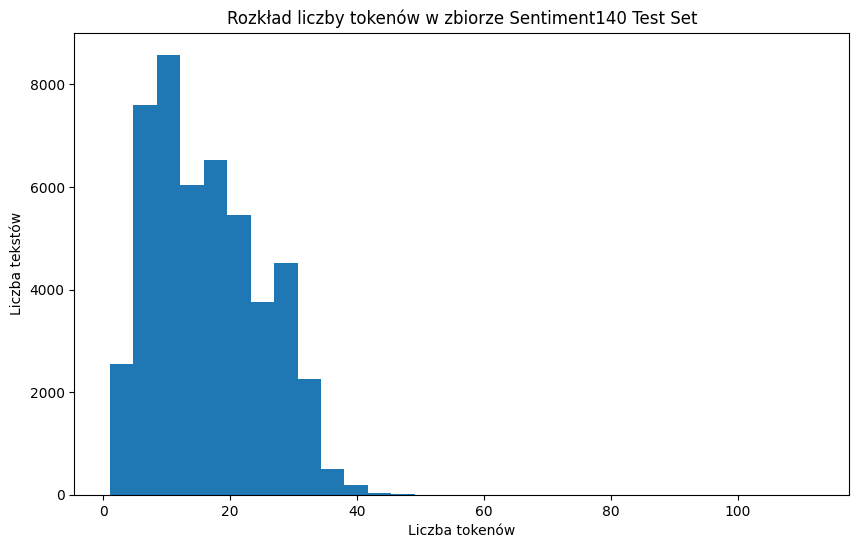

In [164]:
DataUtils.plot_token_distribution(test_sentiment140_df, "Sentiment140 Test Set")

## 2.2. Data Preprocessing

In [165]:
# set preprocessing parameters
vocab_size = 12000  # maximum number of words in the tokenizer
max_length = 64  # maximum length of input sequences

In [166]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_sentiment140_df, max_length=max_length, vocab_size=vocab_size)

In [167]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_sentiment140_df, tokenizer, max_length)

In [168]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_sentiment140_df, tokenizer, max_length)

## 2.3. Model Training

In [169]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [170]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (12000, 300)


In [68]:
# define model architecture
model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                input_length=max_length, weights=[embedding_matrix], 
                trainable=False),
    Conv1D(filters=256, kernel_size=5, activation='relu', padding='same'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

In [69]:
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [70]:
model_cnn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 64, 300)           3600000   
                                                                 
 conv1d_7 (Conv1D)           (None, 64, 256)           384256    
                                                                 
 global_max_pooling1d_4 (Glo  (None, 256)              0         
 balMaxPooling1D)                                                
                                                                 
 dense_6 (Dense)             (None, 128)               32896     
                                                                 
 dropout_7 (Dropout)         (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 1)                 129       
                                                      

In [71]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [72]:
# train the model
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 129s 18ms/step - loss: 0.4838 - accuracy: 0.7668 - val_loss: 0.4552 - val_accuracy: 0.7836
Epoch 2/10
7000/7000 [==============================] - 119s 17ms/step - loss: 0.4356 - accuracy: 0.7975 - val_loss: 0.4478 - val_accuracy: 0.7923
Epoch 3/10
7000/7000 [==============================] - 121s 17ms/step - loss: 0.4093 - accuracy: 0.8122 - val_loss: 0.4291 - val_accuracy: 0.7989
Epoch 4/10
7000/7000 [==============================] - 117s 17ms/step - loss: 0.3855 - accuracy: 0.8234 - val_loss: 0.4374 - val_accuracy: 0.7982
Epoch 5/10
7000/7000 [==============================] - 119s 17ms/step - loss: 0.3622 - accuracy: 0.8354 - val_loss: 0.4422 - val_accuracy: 0.7953


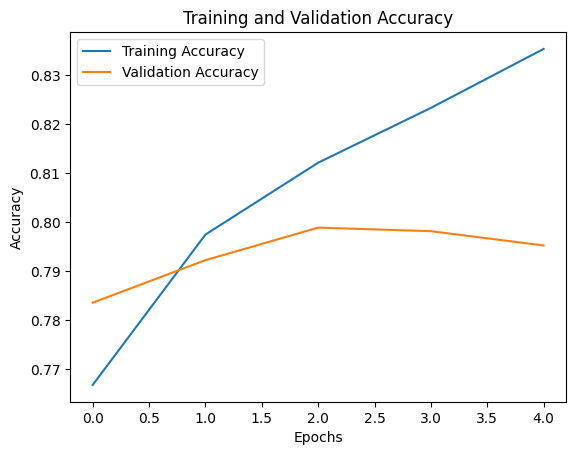

In [73]:
# plot accuracy on training and validation data
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

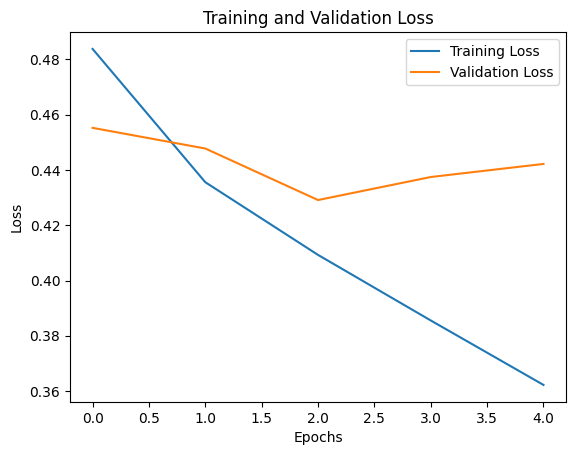

In [74]:
# plot loss on training and validation data
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [75]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_cnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 9s 6ms/step
              precision    recall  f1-score   support

           0       0.79      0.82      0.80     24004
           1       0.81      0.78      0.79     24004

    accuracy                           0.80     48008
   macro avg       0.80      0.80      0.80     48008
weighted avg       0.80      0.80      0.80     48008



## 2.4. Searching for Best Model Parameters

### 2.4.1. BiCNN

In [76]:
def bicnn_sentiment140(vocab_size, learning_rate, embedding_dim, embedding_matrix):
    inputs = Input(shape=(64,))

    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=64, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # forward CNN (left-to-right processing)
    conv_fw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding)
    conv_fw = BatchNormalization()(conv_fw)  
    pool_fw1 = GlobalMaxPooling1D()(conv_fw) 
    pool_fw2 = GlobalAveragePooling1D()(conv_fw) 

    # backward CNN (right-to-left processing)
    reversed_embedding = Lambda(lambda x: tf.reverse(x, axis=[1]))(embedding) 
    conv_bw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(reversed_embedding)
    conv_bw = BatchNormalization()(conv_bw)
    pool_bw1 = GlobalMaxPooling1D()(conv_bw)
    pool_bw2 = GlobalAveragePooling1D()(conv_bw)

    # concatenation of forward and backward features
    concat = Concatenate()([pool_fw1, pool_fw2, pool_bw1, pool_bw2])
    dropout = Dropout(0.5)(concat)  

    # fully connected layer for classification
    dense = Dense(256, activation='relu')(dropout)
    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)

    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model

In [77]:
model_bicnn = bicnn_sentiment140(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [78]:
model_bicnn.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 embedding_4 (Embedding)        (None, 64, 300)      3600000     ['input_3[0][0]']                
                                                                                                  
 lambda_1 (Lambda)              (None, 64, 300)      0           ['embedding_4[0][0]']            
                                                                                                  
 conv1d_8 (Conv1D)              (None, 64, 128)      115328      ['embedding_4[0][0]']            
                                                                                            

In [79]:
# train the model
history_bicnn = model_bicnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 145s 21ms/step - loss: 0.5270 - accuracy: 0.7416 - val_loss: 0.4655 - val_accuracy: 0.7759
Epoch 2/10
7000/7000 [==============================] - 143s 20ms/step - loss: 0.4707 - accuracy: 0.7767 - val_loss: 0.4477 - val_accuracy: 0.7890
Epoch 3/10
7000/7000 [==============================] - 142s 20ms/step - loss: 0.4557 - accuracy: 0.7853 - val_loss: 0.4380 - val_accuracy: 0.7936
Epoch 4/10
7000/7000 [==============================] - 144s 21ms/step - loss: 0.4442 - accuracy: 0.7917 - val_loss: 0.4299 - val_accuracy: 0.8003
Epoch 5/10
7000/7000 [==============================] - 144s 21ms/step - loss: 0.4352 - accuracy: 0.7972 - val_loss: 0.4293 - val_accuracy: 0.7987
Epoch 6/10
7000/7000 [==============================] - 145s 21ms/step - loss: 0.4301 - accuracy: 0.8004 - val_loss: 0.4222 - val_accuracy: 0.8050
Epoch 7/10
7000/7000 [==============================] - 145s 21ms/step - loss: 0.4225 - accuracy: 0.8051 - val_loss: 0

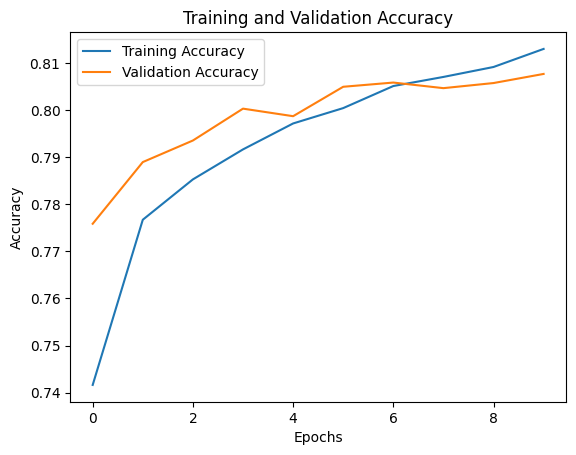

In [80]:
# plot accuracy on training and validation data
plt.plot(history_bicnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_bicnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

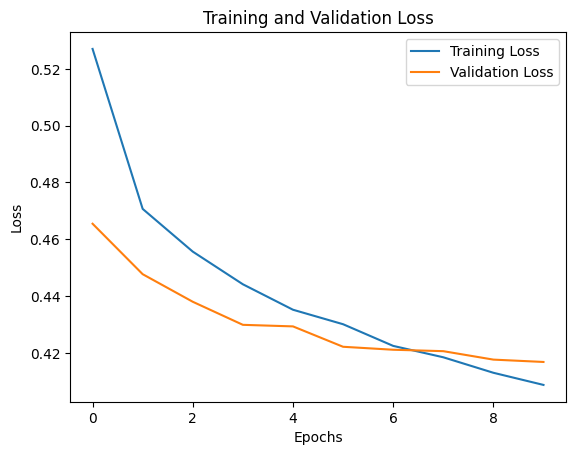

In [81]:
# plot loss on training and validation data
plt.plot(history_bicnn.history['loss'], label='Training Loss')
plt.plot(history_bicnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [82]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bicnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 11s 7ms/step
              precision    recall  f1-score   support

           0       0.81      0.80      0.81     24004
           1       0.80      0.81      0.81     24004

    accuracy                           0.81     48008
   macro avg       0.81      0.81      0.81     48008
weighted avg       0.81      0.81      0.81     48008



### 2.4.2. TCN (Temporal Convolutional Network) 

In [175]:
def tcn_model_sentiment140(vocab_size, learning_rate, embedding_dim, embedding_matrix, dilation_rates=[1,2,4,8]):
    inputs = Input(shape=(64,))
    
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=64, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    x = embedding
    for rate in dilation_rates:
        residual = Conv1D(filters=128, kernel_size=1, padding="same")(x)
        x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same', dilation_rate=rate)(x)
        x = BatchNormalization()(x)
        x = Dropout(0.2)(x)
        x = Add()([x, residual])  
        x = BatchNormalization()(x)
        x = Activation('relu')(x)

    pool1 = GlobalMaxPooling1D()(x)
    pool2 = GlobalAveragePooling1D()(x)
    concat = Concatenate()([pool1, pool2])

    dense = Dense(256, activation='relu')(concat)
    dropout = Dropout(0.3)(dense)
    output = Dense(1, activation='sigmoid')(dropout)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model

In [176]:
model_tcn = tcn_model_sentiment140(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [177]:
model_tcn.summary()

Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_15 (InputLayer)          [(None, 64)]         0           []                               
                                                                                                  
 embedding_17 (Embedding)       (None, 64, 300)      3600000     ['input_15[0][0]']               
                                                                                                  
 conv1d_68 (Conv1D)             (None, 64, 128)      115328      ['embedding_17[0][0]']           
                                                                                                  
 batch_normalization_64 (BatchN  (None, 64, 128)     512         ['conv1d_68[0][0]']              
 ormalization)                                                                              

In [178]:
# train the model
history_tcn = model_tcn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 462s 66ms/step - loss: 0.5086 - accuracy: 0.7530 - val_loss: 0.4835 - val_accuracy: 0.7728
Epoch 2/10
7000/7000 [==============================] - 454s 65ms/step - loss: 0.4533 - accuracy: 0.7890 - val_loss: 0.4410 - val_accuracy: 0.7940
Epoch 3/10
7000/7000 [==============================] - 447s 64ms/step - loss: 0.4332 - accuracy: 0.7996 - val_loss: 0.4368 - val_accuracy: 0.7979
Epoch 4/10
7000/7000 [==============================] - 458s 65ms/step - loss: 0.4176 - accuracy: 0.8088 - val_loss: 0.4184 - val_accuracy: 0.8081
Epoch 5/10
7000/7000 [==============================] - 452s 65ms/step - loss: 0.4068 - accuracy: 0.8143 - val_loss: 0.4174 - val_accuracy: 0.8089
Epoch 6/10
7000/7000 [==============================] - 448s 64ms/step - loss: 0.3969 - accuracy: 0.8195 - val_loss: 0.4154 - val_accuracy: 0.8101
Epoch 7/10
7000/7000 [==============================] - 444s 63ms/step - loss: 0.3885 - accuracy: 0.8235 - val_loss: 0

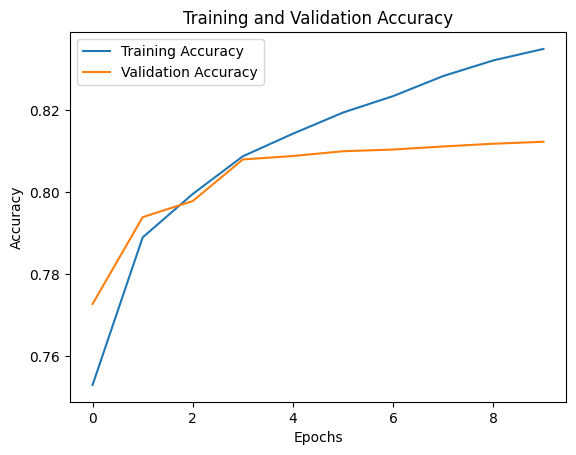

In [179]:
# plot accuracy on training and validation data
plt.plot(history_tcn.history['accuracy'], label='Training Accuracy')
plt.plot(history_tcn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

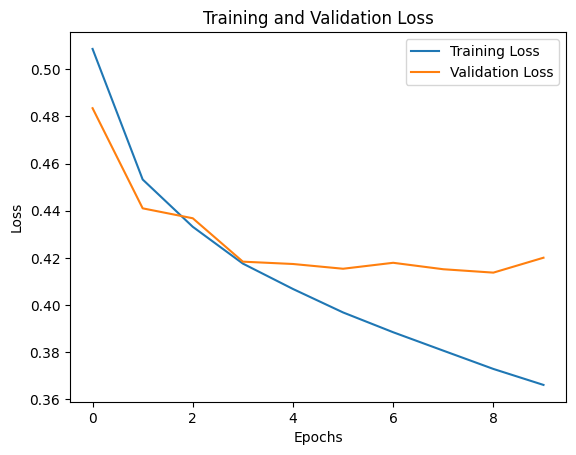

In [180]:
# plot loss on training and validation data
plt.plot(history_tcn.history['loss'], label='Training Loss')
plt.plot(history_tcn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [181]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_tcn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 21s 14ms/step
              precision    recall  f1-score   support

           0       0.81      0.82      0.81     24004
           1       0.82      0.80      0.81     24004

    accuracy                           0.81     48008
   macro avg       0.81      0.81      0.81     48008
weighted avg       0.81      0.81      0.81     48008



## 2.5. Model Evaluation on Test Data

In [90]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_sentiment140_df, max_length=max_length)

1500/1500 [==============================] - 11s 7ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.81      0.80      0.81     24000
           1       0.80      0.82      0.81     24000

    accuracy                           0.81     48000
   macro avg       0.81      0.81      0.81     48000
weighted avg       0.81      0.81      0.81     48000



## 2.6. Model Evaluation on Augmented Data

In [91]:
# load the augmented test sets
test_sentiment140_char_swap_file = '../data/preprocessed/sentiment140_test_char_swap.csv'
test_sentiment140_char_swap_df = pd.read_csv(test_sentiment140_char_swap_file, engine='python', encoding="ISO-8859-1")

test_sentiment140_embedding_file = '../data/preprocessed/sentiment140_test_embedding.csv'
test_sentiment140_embedding_df = pd.read_csv(test_sentiment140_embedding_file, engine='python', encoding="ISO-8859-1")

test_sentiment140_eda_file = '../data/preprocessed/sentiment140_test_eda.csv'
test_sentiment140_eda_df = pd.read_csv(test_sentiment140_eda_file, engine='python', encoding="ISO-8859-1")

In [92]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_sentiment140_char_swap_df, max_length=max_length)

1500/1500 [==============================] - 12s 8ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.75      0.78     24000
           1       0.77      0.81      0.79     24000

    accuracy                           0.78     48000
   macro avg       0.78      0.78      0.78     48000
weighted avg       0.78      0.78      0.78     48000



In [93]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_sentiment140_embedding_df, max_length=max_length)


1500/1500 [==============================] - 12s 8ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.75      0.77     24000
           1       0.77      0.81      0.79     24000

    accuracy                           0.78     48000
   macro avg       0.78      0.78      0.78     48000
weighted avg       0.78      0.78      0.78     48000



In [94]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_sentiment140_eda_df, max_length=max_length)


1500/1500 [==============================] - 12s 8ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.77      0.79     24000
           1       0.78      0.81      0.79     24000

    accuracy                           0.79     48000
   macro avg       0.79      0.79      0.79     48000
weighted avg       0.79      0.79      0.79     48000



## 2.7. Save Model

In [95]:
model_path = os.path.join(models_output_dir, "sentiment140_cnn_model.keras")
model_bicnn.save(model_path)

# 3. CNN Model - Yelp Reviews

## 3.1. Loading Data

In [38]:
# load the dataset
yelp_file = '../data/preprocessed/yelp.csv'
yelp_df = pd.read_csv(yelp_file, engine='python', encoding="ISO-8859-1")

In [39]:
# preview the data
yelp_df.head()

,Polarity,Review
0,0,The food was pretty good but the server was so...
1,0,Horrible manager! She told us we only needed t...
2,1,I Love the Black Bean Burger. So much so I cam...
3,0,Off the beaten path and you can either park yo...
4,1,"Awesome NYC pizza, my second favorite NYC styl..."


In [40]:
train_val_yelp_df, test_yelp_df = train_test_split(
    yelp_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=yelp_df['Polarity']
)

In [41]:
train_yelp_df, val_yelp_df = train_test_split(
    train_val_yelp_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_yelp_df['Polarity']
)

In [42]:
DataUtils.count_reviews_by_polarity(train_yelp_df)

Number of reviews with Polarity=1: 39199
Number of reviews with Polarity=0: 39198


In [43]:
DataUtils.count_reviews_by_polarity(val_yelp_df)

Number of reviews with Polarity=1: 8401
Number of reviews with Polarity=0: 8402


In [44]:
DataUtils.count_reviews_by_polarity(test_yelp_df)

Number of reviews with Polarity=1: 8400
Number of reviews with Polarity=0: 8400


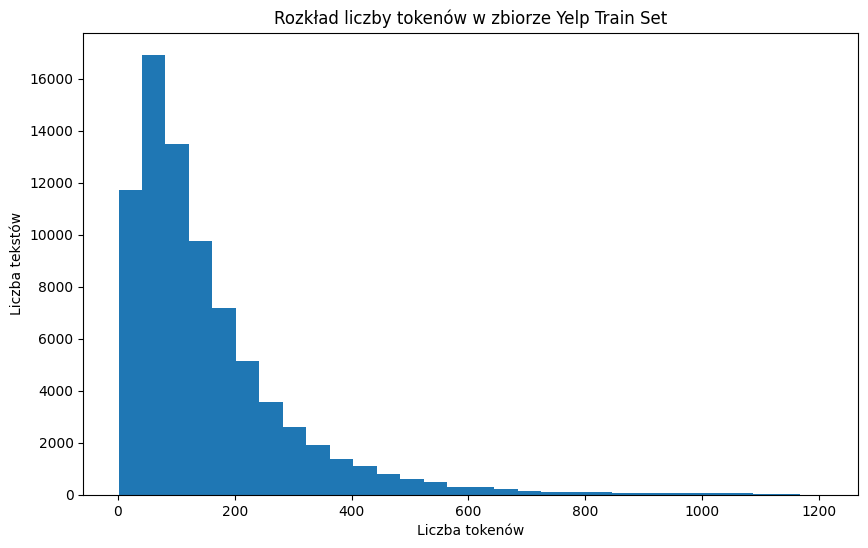

In [45]:
DataUtils.plot_token_distribution(train_yelp_df, "Yelp Train Set")

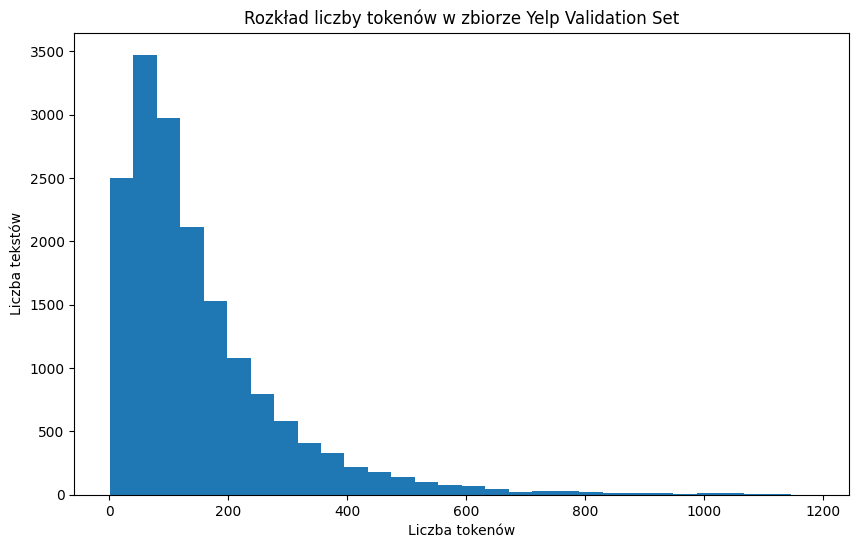

In [46]:
DataUtils.plot_token_distribution(val_yelp_df, "Yelp Validation Set")

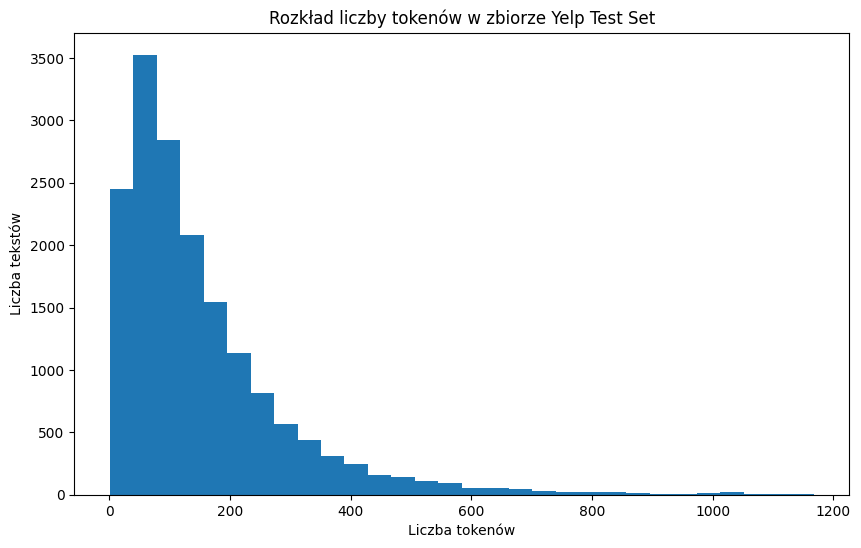

In [47]:
DataUtils.plot_token_distribution(test_yelp_df, "Yelp Test Set")

## 3.2. Data Preprocessing

In [48]:
# set preprocessing parameters
vocab_size = 15000  # maximum number of words in the tokenizer
max_length = 256  # maximum length of input sequences

In [49]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_yelp_df, max_length=max_length, vocab_size=vocab_size)

In [50]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_yelp_df, tokenizer, max_length)

In [51]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_yelp_df, tokenizer, max_length)

## 3.3. Model Training

In [52]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [53]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (15000, 300)


In [24]:
# define model architecture
model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=256, weights=[embedding_matrix], trainable=False),
    
    Conv1D(filters=256, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    
    Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    
    GlobalMaxPooling1D(),
    
    Dense(256, activation='relu'),
    Dropout(0.4),
    
    Dense(1, activation='sigmoid')
])

In [25]:
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [26]:
model_cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 256, 300)          4500000   
                                                                 
 conv1d (Conv1D)             (None, 256, 256)          384256    
                                                                 
 batch_normalization (BatchN  (None, 256, 256)         1024      
 ormalization)                                                   
                                                                 
 conv1d_1 (Conv1D)           (None, 256, 256)          196864    
                                                                 
 batch_normalization_1 (Batc  (None, 256, 256)         1024      
 hNormalization)                                                 
                                                                 
 global_max_pooling1d (Globa  (None, 256)              0

In [59]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [115]:
# train the model
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
2450/2450 [==============================] - 345s 140ms/step - loss: 0.3605 - accuracy: 0.8439 - val_loss: 0.2459 - val_accuracy: 0.8967
Epoch 2/10
2450/2450 [==============================] - 340s 139ms/step - loss: 0.2352 - accuracy: 0.9057 - val_loss: 0.2114 - val_accuracy: 0.9121
Epoch 3/10
2450/2450 [==============================] - 342s 140ms/step - loss: 0.1999 - accuracy: 0.9216 - val_loss: 0.2236 - val_accuracy: 0.9016
Epoch 4/10
2450/2450 [==============================] - 346s 141ms/step - loss: 0.1719 - accuracy: 0.9343 - val_loss: 0.1948 - val_accuracy: 0.9213
Epoch 5/10
2450/2450 [==============================] - 341s 139ms/step - loss: 0.1430 - accuracy: 0.9463 - val_loss: 0.1935 - val_accuracy: 0.9211
Epoch 6/10
2450/2450 [==============================] - 350s 143ms/step - loss: 0.1211 - accuracy: 0.9545 - val_loss: 0.2396 - val_accuracy: 0.9158
Epoch 7/10
2450/2450 [==============================] - 352s 144ms/step - loss: 0.0995 - accuracy: 0.9635 - val_

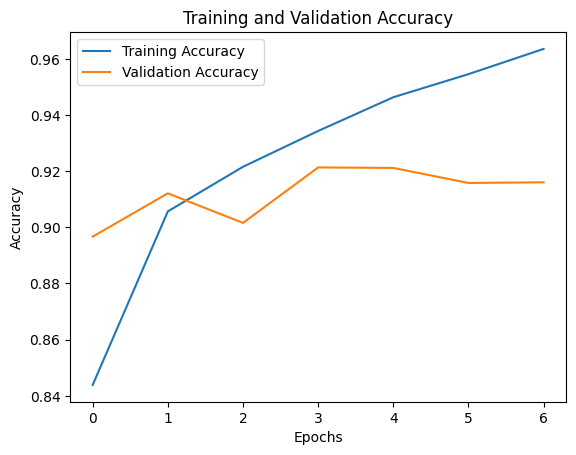

In [116]:
# plot accuracy on training and validation data
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

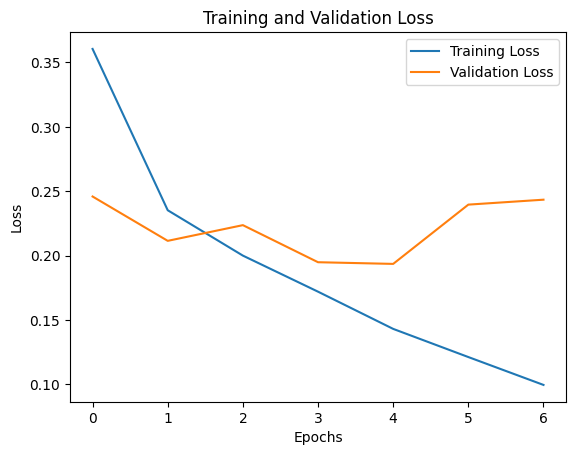

In [117]:
# plot loss on training and validation data
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [118]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_cnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
526/526 [==============================] - 14s 27ms/step
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      8402
           1       0.94      0.90      0.92      8401

    accuracy                           0.92     16803
   macro avg       0.92      0.92      0.92     16803
weighted avg       0.92      0.92      0.92     16803



## 3.4. Searching for Best Model Parameters

### 3.4.1. BiCNN

In [27]:
def bicnn_yelp(vocab_size, learning_rate, embedding_dim, embedding_matrix):
    inputs = Input(shape=(256,))

    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=256, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # forward CNN (left-to-right processing)
    conv_fw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding)
    conv_fw = BatchNormalization()(conv_fw)
    conv_fw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(conv_fw)
    conv_fw = BatchNormalization()(conv_fw)
    pool_fw1 = GlobalMaxPooling1D()(conv_fw)
    pool_fw2 = GlobalAveragePooling1D()(conv_fw)

    # reverse input sequence to process right-to-left
    reversed_embedding = Lambda(lambda x: tf.reverse(x, axis=[1]))(embedding)
                              
    # backward CNN (right-to-left processing)
    conv_bw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(reversed_embedding)
    conv_bw = BatchNormalization()(conv_bw)
    conv_bw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(conv_bw)
    conv_bw = BatchNormalization()(conv_bw)
    conv_bw = Dropout(0.3)(conv_bw)
    pool_bw1 = GlobalMaxPooling1D()(conv_bw)
    pool_bw2 = GlobalAveragePooling1D()(conv_bw)

    concat = Concatenate()([pool_fw1, pool_fw2, pool_bw1, pool_bw2])
    dropout = Dropout(0.5)(concat)

    dense = Dense(256, activation='relu')(dropout)
    dense = BatchNormalization()(dense)
    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model

In [28]:
model_bicnn = bicnn_yelp(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [29]:
model_bicnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [30]:
model_bicnn.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256)]        0           []                               
                                                                                                  
 embedding_1 (Embedding)        (None, 256, 300)     4500000     ['input_1[0][0]']                
                                                                                                  
 lambda (Lambda)                (None, 256, 300)     0           ['embedding_1[0][0]']            
                                                                                                  
 conv1d_4 (Conv1D)              (None, 256, 128)     115328      ['lambda[0][0]']                 
                                                                                              

In [122]:
# train the model
history_bicnn = model_bicnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
2450/2450 [==============================] - 328s 133ms/step - loss: 0.3481 - accuracy: 0.8431 - val_loss: 0.2279 - val_accuracy: 0.9070
Epoch 2/10
2450/2450 [==============================] - 319s 130ms/step - loss: 0.2402 - accuracy: 0.9016 - val_loss: 0.2134 - val_accuracy: 0.9131
Epoch 3/10
2450/2450 [==============================] - 318s 130ms/step - loss: 0.2124 - accuracy: 0.9148 - val_loss: 0.2065 - val_accuracy: 0.9190
Epoch 4/10
2450/2450 [==============================] - 316s 129ms/step - loss: 0.1905 - accuracy: 0.9236 - val_loss: 0.2082 - val_accuracy: 0.9147
Epoch 5/10
2450/2450 [==============================] - 315s 129ms/step - loss: 0.1742 - accuracy: 0.9321 - val_loss: 0.1925 - val_accuracy: 0.9213
Epoch 6/10
2450/2450 [==============================] - 317s 129ms/step - loss: 0.1631 - accuracy: 0.9369 - val_loss: 0.1922 - val_accuracy: 0.9250
Epoch 7/10
2450/2450 [==============================] - 317s 130ms/step - loss: 0.1523 - accuracy: 0.9413 - val_

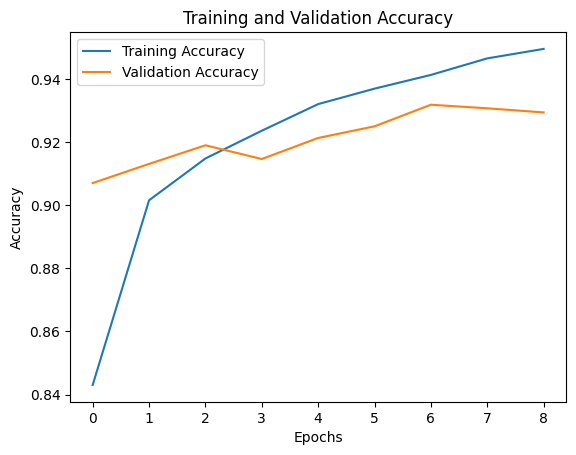

In [123]:
# plot accuracy on training and validation data
plt.plot(history_bicnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_bicnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

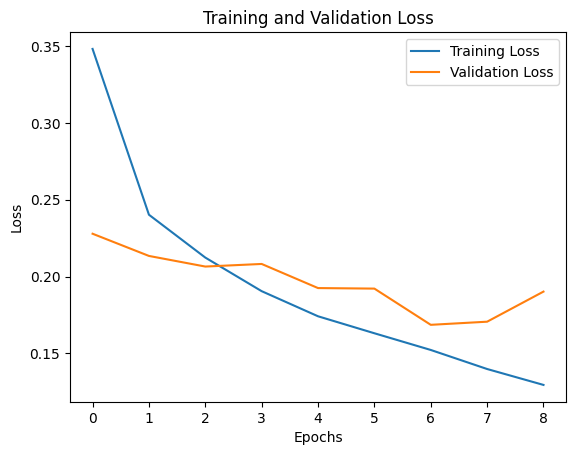

In [124]:
# plot loss on training and validation data
plt.plot(history_bicnn.history['loss'], label='Training Loss')
plt.plot(history_bicnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [125]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bicnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
526/526 [==============================] - 12s 22ms/step
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      8402
           1       0.93      0.93      0.93      8401

    accuracy                           0.93     16803
   macro avg       0.93      0.93      0.93     16803
weighted avg       0.93      0.93      0.93     16803



### 3.4.2. TCN (Temporal Convolutional Network) 

In [54]:
def tcn_model_yelp(vocab_size, learning_rate, embedding_dim, embedding_matrix, dilation_rates=[1,2,4,8,16,32]):
    inputs = Input(shape=(256,))
    
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=256, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    x = embedding
    for rate in dilation_rates:
        residual = Conv1D(filters=128, kernel_size=1, padding="same")(x)  
        x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same', dilation_rate=rate)(x)
        x = BatchNormalization()(x)
        x = Dropout(0.2)(x)
        x = Add()([x, residual])  
        x = BatchNormalization()(x)
        x = Activation('relu')(x)

    pool1 = GlobalMaxPooling1D()(x)
    pool2 = GlobalAveragePooling1D()(x)
    concat = Concatenate()([pool1, pool2])

    dense = Dense(256, activation='relu')(concat)
    dropout = Dropout(0.3)(dense)
    output = Dense(1, activation='sigmoid')(dropout)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model

In [56]:
model_tcn = tcn_model_yelp(vocab_size=vocab_size, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix, learning_rate=learning_rate)

In [57]:
model_tcn.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 256)]        0           []                               
                                                                                                  
 embedding_2 (Embedding)        (None, 256, 300)     4500000     ['input_2[0][0]']                
                                                                                                  
 conv1d_7 (Conv1D)              (None, 256, 128)     115328      ['embedding_2[0][0]']            
                                                                                                  
 batch_normalization_7 (BatchNo  (None, 256, 128)    512         ['conv1d_7[0][0]']               
 rmalization)                                                                               

In [61]:
# train the model
history_tcn = model_tcn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
2450/2450 [==============================] - 806s 328ms/step - loss: 0.3691 - accuracy: 0.8296 - val_loss: 0.2652 - val_accuracy: 0.8880
Epoch 2/10
2450/2450 [==============================] - 803s 328ms/step - loss: 0.2407 - accuracy: 0.9032 - val_loss: 0.3123 - val_accuracy: 0.8695
Epoch 3/10
2450/2450 [==============================] - 788s 321ms/step - loss: 0.2103 - accuracy: 0.9163 - val_loss: 0.1849 - val_accuracy: 0.9238
Epoch 4/10
2450/2450 [==============================] - 817s 333ms/step - loss: 0.1898 - accuracy: 0.9240 - val_loss: 0.1784 - val_accuracy: 0.9275
Epoch 5/10
2450/2450 [==============================] - 806s 329ms/step - loss: 0.1728 - accuracy: 0.9329 - val_loss: 0.1704 - val_accuracy: 0.9317
Epoch 6/10
2450/2450 [==============================] - 810s 330ms/step - loss: 0.1620 - accuracy: 0.9369 - val_loss: 0.1623 - val_accuracy: 0.9346
Epoch 7/10
2450/2450 [==============================] - 804s 328ms/step - loss: 0.1501 - accuracy: 0.9428 - val_

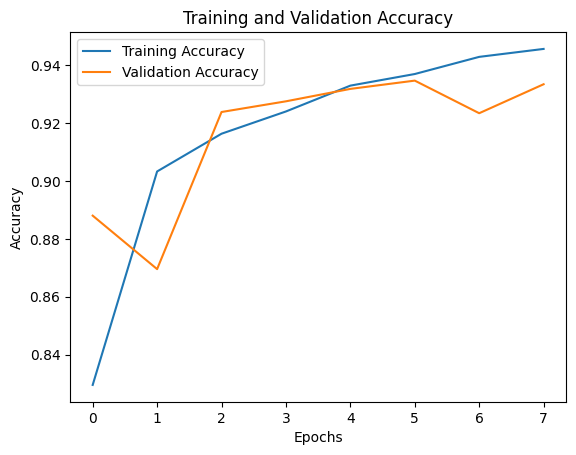

In [62]:
# plot accuracy on training and validation data
plt.plot(history_tcn.history['accuracy'], label='Training Accuracy')
plt.plot(history_tcn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

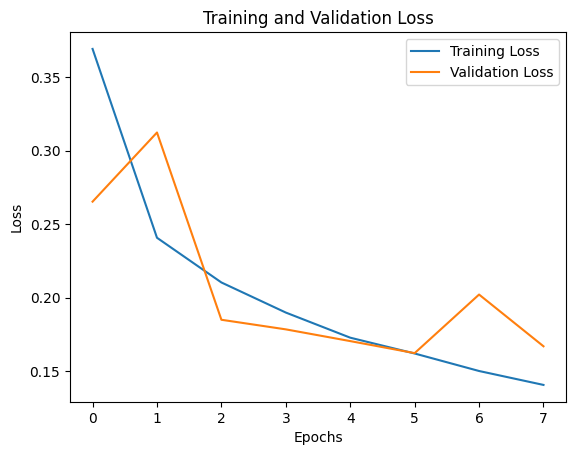

In [63]:
# plot loss on training and validation data
plt.plot(history_tcn.history['loss'], label='Training Loss')
plt.plot(history_tcn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [64]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_tcn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
526/526 [==============================] - 27s 51ms/step
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      8402
           1       0.94      0.93      0.93      8401

    accuracy                           0.93     16803
   macro avg       0.93      0.93      0.93     16803
weighted avg       0.93      0.93      0.93     16803



## 3.5. Model Evaluation on Test Data

In [65]:
train_cnn.evaluate_model(model=model_tcn, tokenizer=tokenizer, test_df=test_yelp_df, max_length=max_length)

525/525 [==============================] - 28s 53ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      8400
           1       0.94      0.93      0.93      8400

    accuracy                           0.93     16800
   macro avg       0.93      0.93      0.93     16800
weighted avg       0.93      0.93      0.93     16800



## 3.6. Model Evaluation on Augmented Data

In [66]:
# load the augmented test sets
test_yelp_char_swap_file = '../data/preprocessed/yelp_test_char_swap.csv'
test_yelp_char_swap_df = pd.read_csv(test_yelp_char_swap_file, engine='python', encoding="ISO-8859-1")

test_yelp_transform_file = '../data/preprocessed/yelp_test_transform.csv'
test_yelp_transform_df = pd.read_csv(test_yelp_transform_file, engine='python', encoding="ISO-8859-1")

test_yelp_combined_file = '../data/preprocessed/yelp_test_combined.csv'
test_yelp_combined_df = pd.read_csv(test_yelp_combined_file, engine='python', encoding="ISO-8859-1")

In [67]:
train_cnn.evaluate_model(model=model_tcn, tokenizer=tokenizer, test_df=test_yelp_char_swap_df, max_length=max_length)

525/525 [==============================] - 27s 51ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.81      0.91      0.86      8400
           1       0.90      0.78      0.84      8400

    accuracy                           0.85     16800
   macro avg       0.85      0.85      0.85     16800
weighted avg       0.85      0.85      0.85     16800



In [68]:
train_cnn.evaluate_model(model=model_tcn, tokenizer=tokenizer, test_df=test_yelp_transform_df, max_length=max_length)


525/525 [==============================] - 27s 50ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.90      0.93      0.92      8400
           1       0.93      0.90      0.91      8400

    accuracy                           0.91     16800
   macro avg       0.92      0.91      0.91     16800
weighted avg       0.92      0.91      0.91     16800



In [69]:
train_cnn.evaluate_model(model=model_tcn, tokenizer=tokenizer, test_df=test_yelp_combined_df, max_length=max_length)


525/525 [==============================] - 28s 53ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.78      0.90      0.83      8400
           1       0.88      0.74      0.81      8400

    accuracy                           0.82     16800
   macro avg       0.83      0.82      0.82     16800
weighted avg       0.83      0.82      0.82     16800



## 3.7. Save Model

In [70]:
model_path = os.path.join(models_output_dir, "yelp_cnn_model.keras")
model_tcn.save(model_path)